Imports and paths

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print("Seaborn not installed. Heatmaps will use matplotlib.")

PROJECT_ROOT = Path(".")
SAVED_DIR = PROJECT_ROOT / "saved_outputs"
SAVED_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Saved outputs:", SAVED_DIR.resolve())

Project root: C:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8
Saved outputs: C:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs


Check available result files

In [2]:
result_extensions = {".csv", ".json", ".npy", ".npz", ".pkl", ".pt", ".png"}

result_files = [
    f for f in PROJECT_ROOT.rglob("*")
    if f.is_file() and f.suffix.lower() in result_extensions
]

print(f"Found {len(result_files)} result files:\n")

for f in result_files:
    print(f)

Found 19 result files:

models\cifar10\Linf\Engstrom2019Robustness.pt
models\cifar10\Linf\Rice2020Overfitting.pt
models\cifar10\Linf\Standard.pt
models\cifar10\Linf\Wong2020Fast.pt
saved_outputs\asr_results.csv
saved_outputs\cka_results.csv
saved_outputs\gaas_results.csv
saved_outputs\model_info.csv
saved_outputs\sat_results.csv
saved_outputs\selected_layers.csv
saved_outputs\transferability_long.csv
saved_outputs\transferability_matrix.csv
saved_outputs\transferable_example_cka.csv
saved_outputs\x_adv_pgd_Engstrom2019Robustness_eps8_255_n64.pt
saved_outputs\x_adv_pgd_Rice2020Overfitting_eps8_255_n64.pt
saved_outputs\x_adv_pgd_Standard_eps8_255_n64.pt
saved_outputs\x_adv_pgd_Wong2020Fast_eps8_255_n64.pt
saved_outputs\perturbations\cifar10_engstrom_linf_eps8_adv.pt
saved_outputs\perturbations\cifar10_standard_linf_eps8_adv.pt


Set file paths

In [3]:
CKA_PATH = SAVED_DIR / "cka_results.csv"
SAT_PATH = SAVED_DIR / "sat_results.csv"
GAAS_PATH = SAVED_DIR / "gaas_results.csv"
TRANSFER_PATH = SAVED_DIR / "transferability_matrix.csv"
ASR_PATH = SAVED_DIR / "asr_results.csv"
MODEL_INFO_PATH = SAVED_DIR / "model_info.csv"

paths = {
    "CKA": CKA_PATH,
    "SAT": SAT_PATH,
    "GAAS": GAAS_PATH,
    "Transferability": TRANSFER_PATH,
    "ASR": ASR_PATH,
    "Model info": MODEL_INFO_PATH,
}

for name, path in paths.items():
    print(f"{name}: {path} | exists = {path.exists()}")

CKA: saved_outputs\cka_results.csv | exists = True
SAT: saved_outputs\sat_results.csv | exists = True
GAAS: saved_outputs\gaas_results.csv | exists = True
Transferability: saved_outputs\transferability_matrix.csv | exists = True
ASR: saved_outputs\asr_results.csv | exists = True
Model info: saved_outputs\model_info.csv | exists = True


Safe loader

In [4]:
def safe_read_csv(path, name):
    path = Path(path)
    
    if path.exists():
        df = pd.read_csv(path)
        print(f"Loaded {name}: {df.shape}")
        display(df.head())
        return df
    
    print(f"Missing {name}: {path}")
    return None


cka_df = safe_read_csv(CKA_PATH, "CKA")
sat_df = safe_read_csv(SAT_PATH, "SAT")
gaas_df = safe_read_csv(GAAS_PATH, "GAAS")
transfer_df = safe_read_csv(TRANSFER_PATH, "Transferability")
asr_df = safe_read_csv(ASR_PATH, "ASR")
model_info_df = safe_read_csv(MODEL_INFO_PATH, "Model info")

Loaded CKA: (432, 8)


,source_model,target_model,source_layer,target_layer,source_layer_name,target_layer_name,cka,n_examples
0,Standard,Engstrom2019Robustness,1,1,conv1,conv1,0.907794,64
1,Standard,Engstrom2019Robustness,1,2,conv1,layer2.0.conv1,0.841922,64
2,Standard,Engstrom2019Robustness,1,3,conv1,layer2.3.conv1,0.765733,64
3,Standard,Engstrom2019Robustness,1,4,conv1,layer3.2.conv2,0.659945,64
4,Standard,Engstrom2019Robustness,1,5,conv1,layer3.5.conv3,0.494516,64


Loaded SAT: (16, 3)


,source_model,target_model,sat
0,Standard,Standard,1.000000
1,Standard,Engstrom2019Robustness,0.101695
2,Standard,Wong2020Fast,0.135593
3,Standard,Rice2020Overfitting,0.118644
4,Engstrom2019Robustness,Standard,0.346154


Loaded GAAS: (12, 5)


...

,source_model,Engstrom2019Robustness,Rice2020Overfitting,Standard,Wong2020Fast
0,Engstrom2019Robustness,1.000000,0.500000,0.346154,0.769231
1,Rice2020Overfitting,0.578947,1.000000,0.263158,0.684211
2,Standard,0.101695,0.118644,1.000000,0.135593
3,Wong2020Fast,0.500000,0.428571,0.357143,1.000000


Loaded ASR: (4, 7)


,model,clean_accuracy,robust_accuracy_pgd,asr_pgd,n_examples,eps,pgd_steps
0,Standard,0.921875,0.000000,1.000000,64,0.031373,10
1,Engstrom2019Robustness,0.890625,0.484375,0.515625,64,0.031373,10
2,Wong2020Fast,0.843750,0.406250,0.593750,64,0.031373,10
3,Rice2020Overfitting,0.843750,0.546875,0.453125,64,0.031373,10


Loaded Model info: (4, 3)


,model,architecture,training_type
0,Standard,ResNet,standard
1,Engstrom2019Robustness,ResNet,adversarial_training
2,Wong2020Fast,WideResNet,fast_adversarial_training
3,Rice2020Overfitting,WideResNet,adversarial_training


Convert transferability matrix to long format

In [5]:
def transfer_matrix_to_long(df):
    source_col = df.columns[0]
    
    long_df = df.melt(
        id_vars=source_col,
        var_name="target_model",
        value_name="transfer_asr"
    )
    
    long_df = long_df.rename(columns={source_col: "source_model"})
    return long_df


if transfer_df is not None:
    if "target_model" not in transfer_df.columns:
        transfer_long_df = transfer_matrix_to_long(transfer_df)
    else:
        transfer_long_df = transfer_df.copy()
    
    display(transfer_long_df.head())
else:
    transfer_long_df = None

,source_model,target_model,transfer_asr
0,Engstrom2019Robustness,Engstrom2019Robustness,1.000000
1,Rice2020Overfitting,Engstrom2019Robustness,0.578947
2,Standard,Engstrom2019Robustness,0.101695
3,Wong2020Fast,Engstrom2019Robustness,0.500000
4,Engstrom2019Robustness,Rice2020Overfitting,0.500000


Layer-wise CKA analysis

In [6]:
def get_layerwise_cka(cka_df):
    required = {
        "source_model",
        "target_model",
        "source_layer",
        "target_layer",
        "cka"
    }
    
    missing = required - set(cka_df.columns)
    
    if missing:
        raise ValueError(f"CKA dataframe is missing columns: {missing}")
    
    layerwise = cka_df[
        cka_df["source_layer"] == cka_df["target_layer"]
    ].copy()
    
    layerwise = layerwise.rename(columns={"source_layer": "layer"})
    
    return layerwise[
        ["source_model", "target_model", "layer", "cka"]
    ]


if cka_df is not None:
    layerwise_cka_df = get_layerwise_cka(cka_df)
    display(layerwise_cka_df.head())
else:
    layerwise_cka_df = None

,source_model,target_model,layer,cka
0,Standard,Engstrom2019Robustness,1,0.907794
7,Standard,Engstrom2019Robustness,2,0.857206
14,Standard,Engstrom2019Robustness,3,0.883064
21,Standard,Engstrom2019Robustness,4,0.828372
28,Standard,Engstrom2019Robustness,5,0.787117


Plot layer-wise CKA

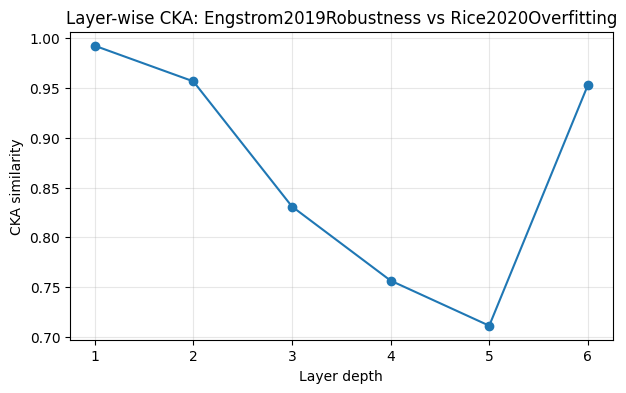

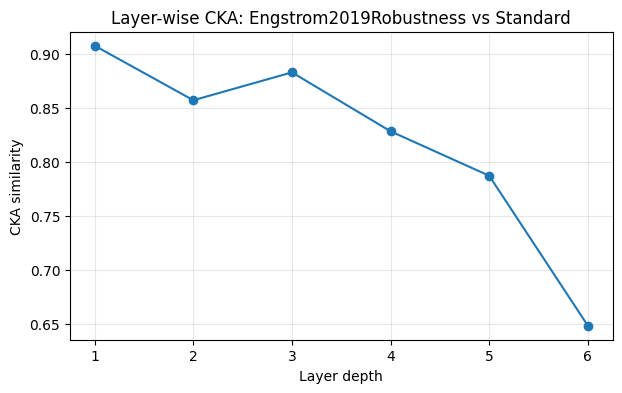

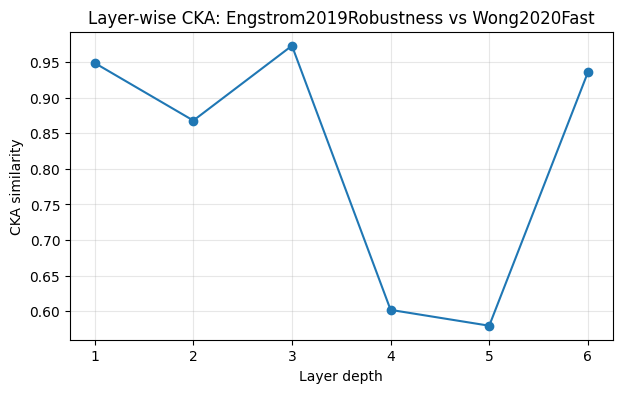

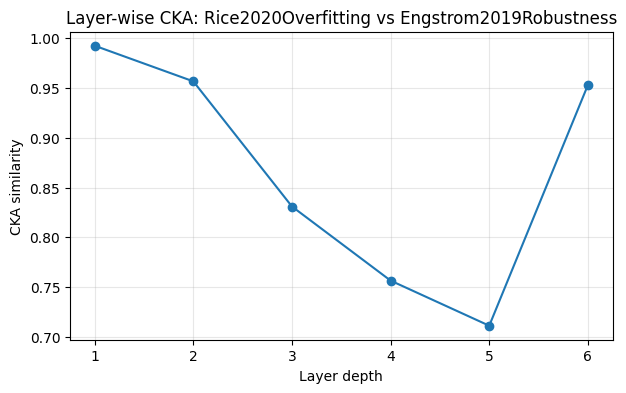

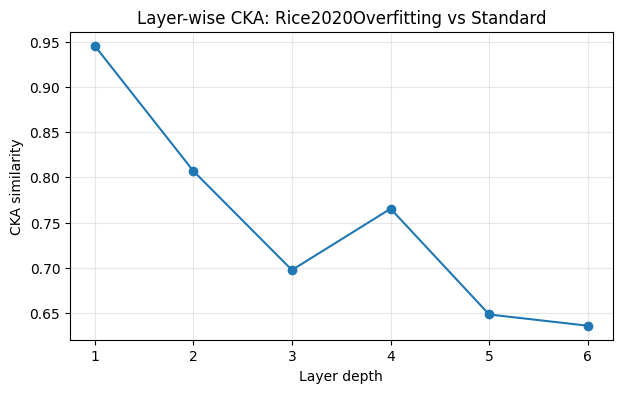

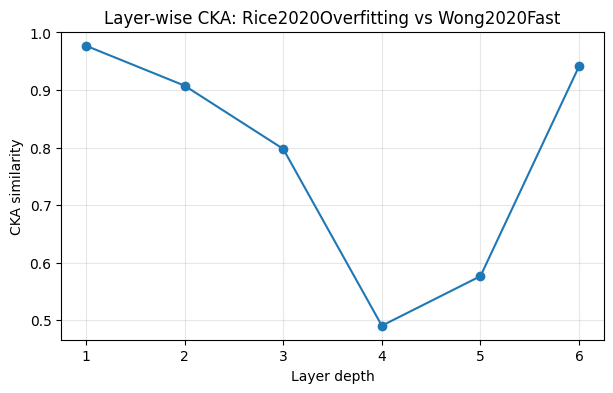

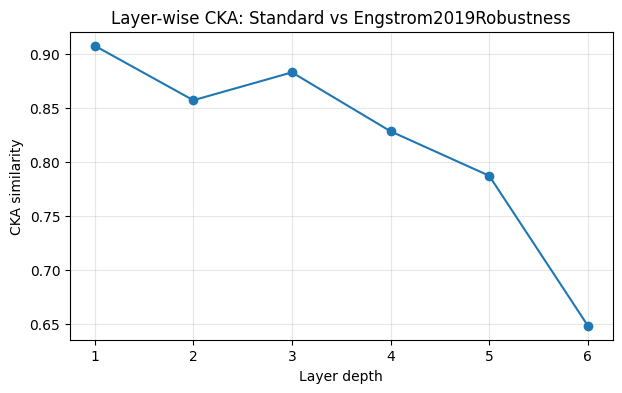

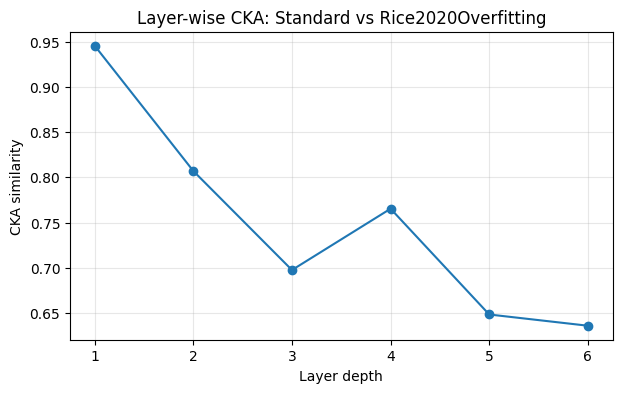

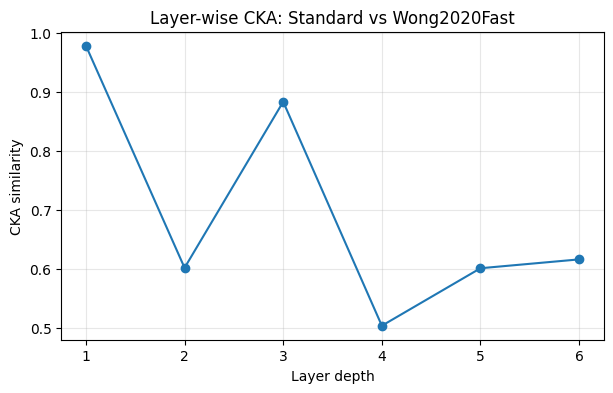

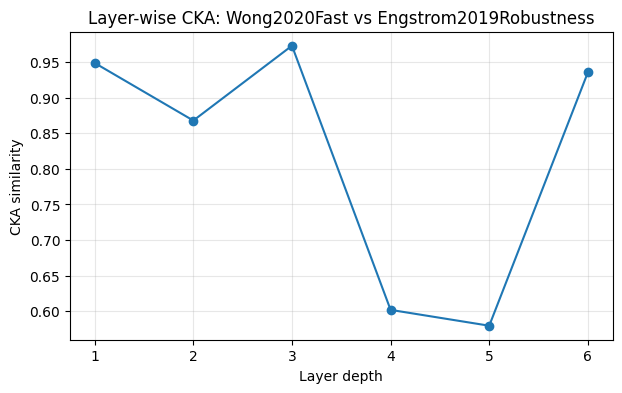

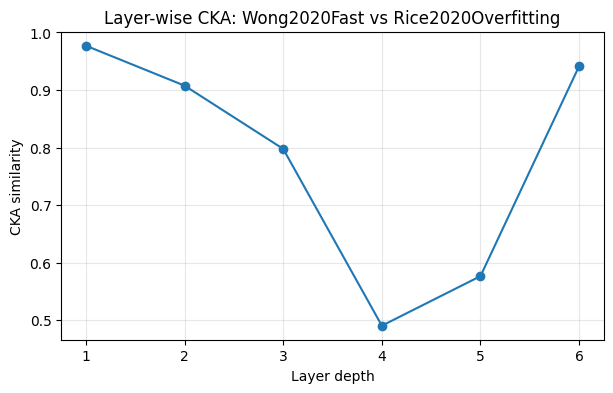

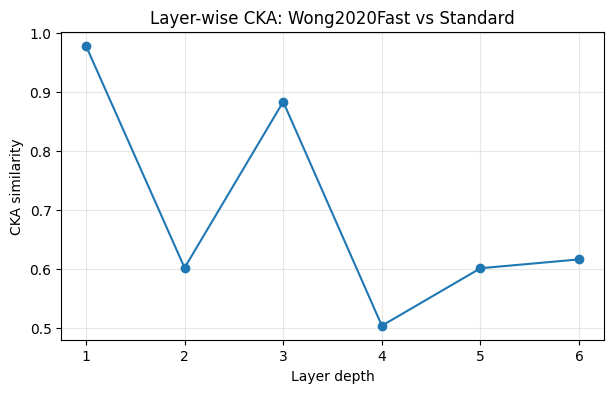

In [7]:
if layerwise_cka_df is not None:
    for (src, tgt), group in layerwise_cka_df.groupby(["source_model", "target_model"]):
        group = group.sort_values("layer")
        
        plt.figure(figsize=(7, 4))
        plt.plot(group["layer"], group["cka"], marker="o")
        plt.xlabel("Layer depth")
        plt.ylabel("CKA similarity")
        plt.title(f"Layer-wise CKA: {src} vs {tgt}")
        plt.grid(True, alpha=0.3)
        plt.show()

Cross-layer CKA analysis

In [8]:
def plot_cross_layer_cka(cka_df, source_model, target_model):
    pair = cka_df[
        (cka_df["source_model"] == source_model) &
        (cka_df["target_model"] == target_model)
    ].copy()
    
    if pair.empty:
        print(f"No CKA data for {source_model} vs {target_model}")
        return
    
    matrix = pair.pivot_table(
        index="source_layer",
        columns="target_layer",
        values="cka",
        aggfunc="mean"
    )
    
    plt.figure(figsize=(7, 6))
    
    if HAS_SEABORN:
        sns.heatmap(matrix, annot=True, fmt=".2f")
    else:
        plt.imshow(matrix.values, aspect="auto")
        plt.colorbar(label="CKA")
        plt.xticks(range(len(matrix.columns)), matrix.columns)
        plt.yticks(range(len(matrix.index)), matrix.index)
    
    plt.xlabel(f"{target_model} layers")
    plt.ylabel(f"{source_model} layers")
    plt.title(f"Cross-layer CKA: {source_model} vs {target_model}")
    plt.show()

Plot cross-layer CKA for all pairs

,source_model,target_model
0,Standard,Engstrom2019Robustness
36,Standard,Wong2020Fast
72,Standard,Rice2020Overfitting
108,Engstrom2019Robustness,Standard
144,Engstrom2019Robustness,Wong2020Fast
180,Engstrom2019Robustness,Rice2020Overfitting
216,Wong2020Fast,Standard
252,Wong2020Fast,Engstrom2019Robustness
288,Wong2020Fast,Rice2020Overfitting
324,Rice2020Overfitting,Standard


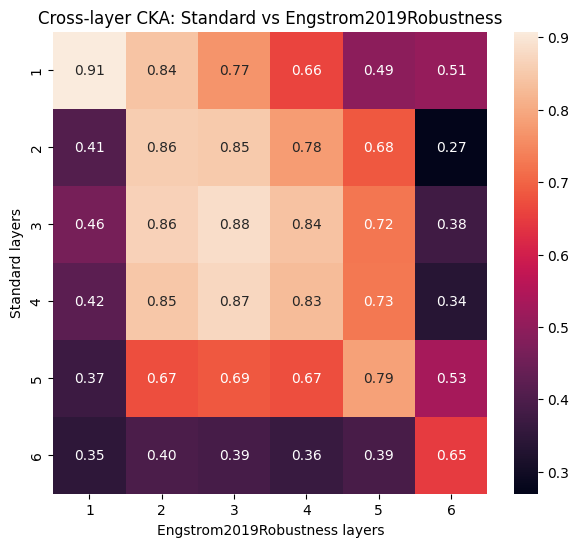

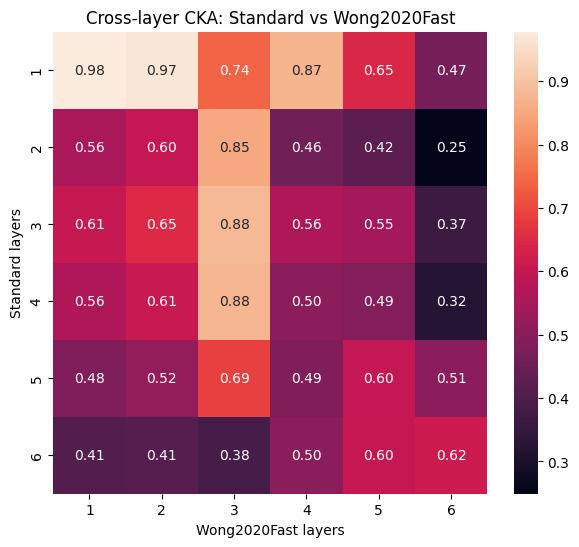

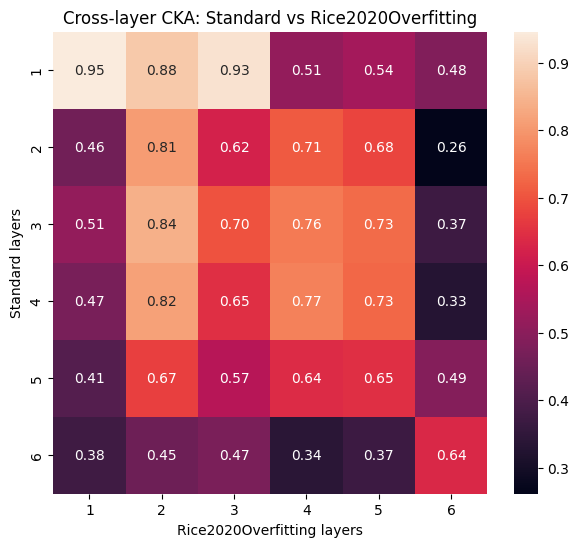

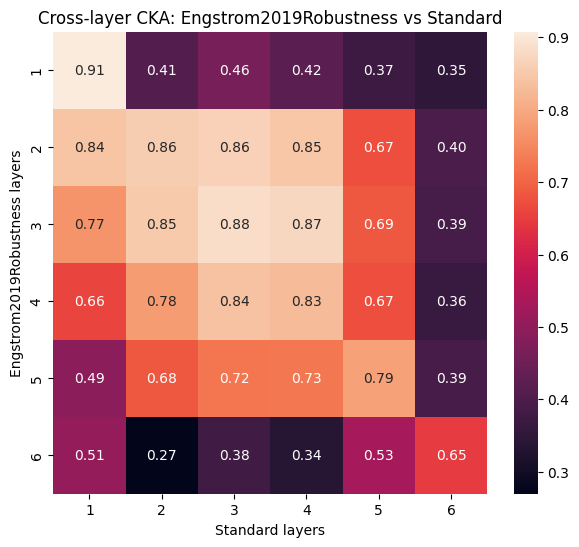

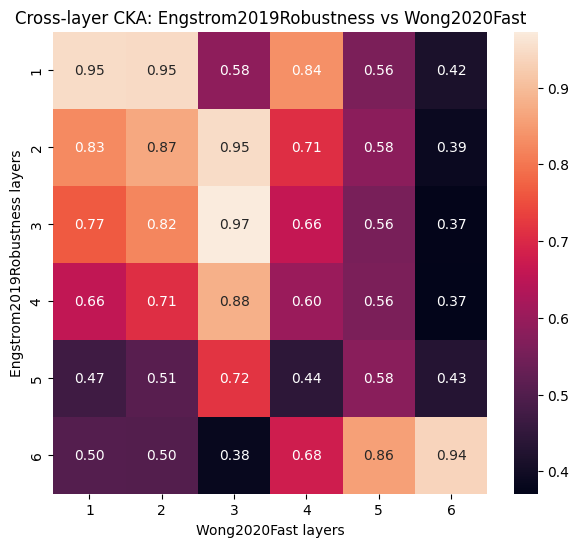

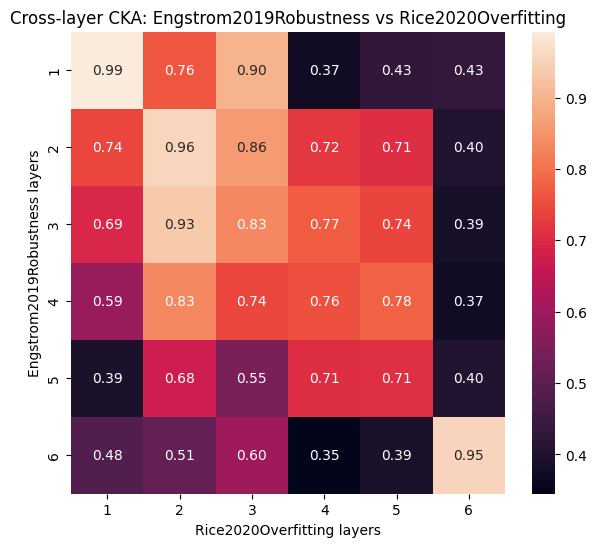

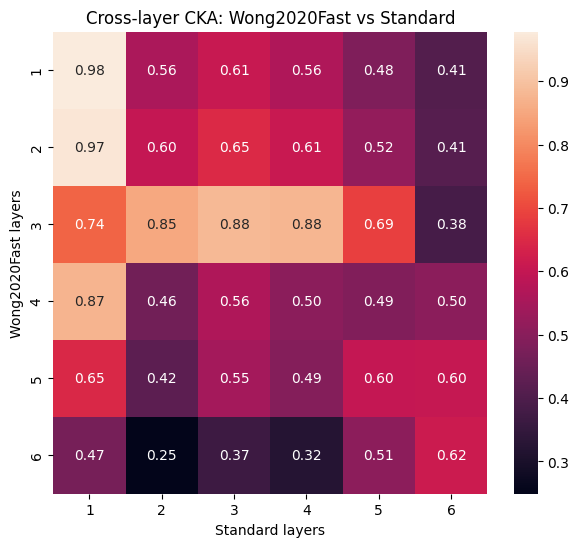

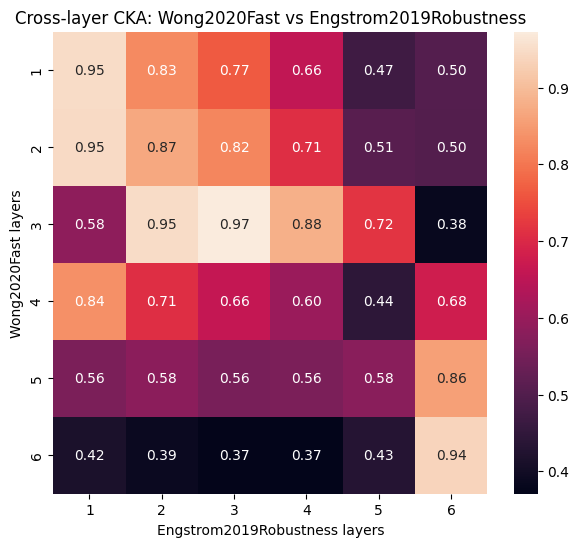

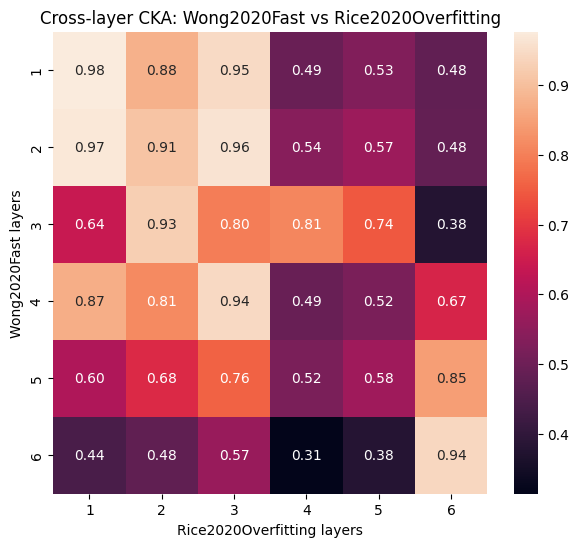

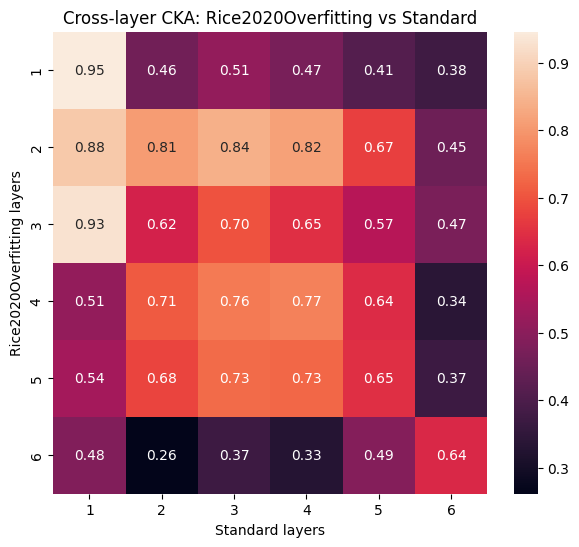

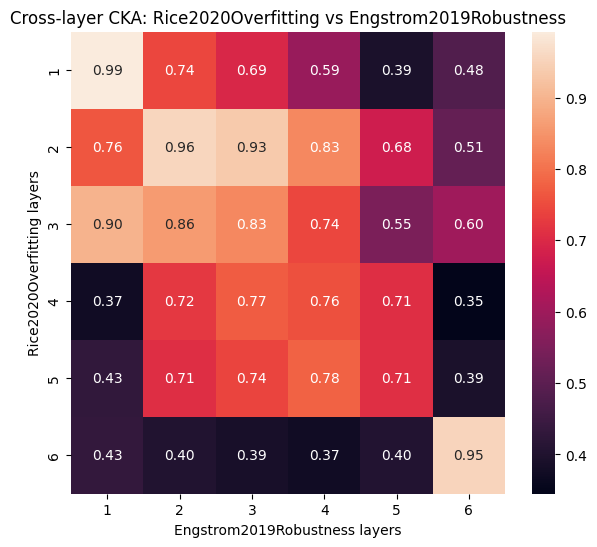

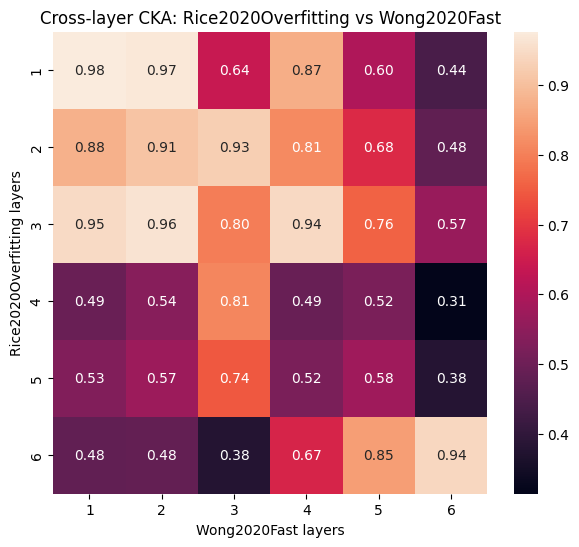

In [9]:
if cka_df is not None:
    model_pairs = cka_df[["source_model", "target_model"]].drop_duplicates()
    display(model_pairs)
    
    for _, row in model_pairs.iterrows():
        plot_cross_layer_cka(
            cka_df,
            row["source_model"],
            row["target_model"]
        )

Build pairwise summary

In [10]:
def build_pairwise_summary(
    cka_df=None,
    sat_df=None,
    gaas_df=None,
    transfer_long_df=None,
    model_info_df=None
):
    summary = None
    
    if cka_df is not None:
        same_layer = cka_df[
            cka_df["source_layer"] == cka_df["target_layer"]
        ].copy()
        
        cka_summary = same_layer.groupby(
            ["source_model", "target_model"]
        ).agg(
            mean_cka=("cka", "mean"),
            max_cka=("cka", "max")
        ).reset_index()
        
        best_layers = (
            same_layer.sort_values("cka", ascending=False)
            .groupby(["source_model", "target_model"])
            .first()
            .reset_index()
            [["source_model", "target_model", "source_layer"]]
            .rename(columns={"source_layer": "best_layer"})
        )
        
        cka_summary = cka_summary.merge(
            best_layers,
            on=["source_model", "target_model"],
            how="left"
        )
        
        summary = cka_summary
    
    if sat_df is not None:
        sat_temp = sat_df[["source_model", "target_model", "sat"]].copy()
        summary = sat_temp if summary is None else summary.merge(
            sat_temp,
            on=["source_model", "target_model"],
            how="outer"
        )
    
    if gaas_df is not None:
        gaas_temp = gaas_df[["source_model", "target_model", "gaas"]].copy()
        summary = gaas_temp if summary is None else summary.merge(
            gaas_temp,
            on=["source_model", "target_model"],
            how="outer"
        )
    
    if transfer_long_df is not None:
        transfer_temp = transfer_long_df[
            ["source_model", "target_model", "transfer_asr"]
        ].copy()
        
        summary = transfer_temp if summary is None else summary.merge(
            transfer_temp,
            on=["source_model", "target_model"],
            how="outer"
        )
    
    if model_info_df is not None and summary is not None:
        src_info = model_info_df.rename(columns={
            "model": "source_model",
            "architecture": "source_architecture",
            "training_type": "source_training_type"
        })
        
        tgt_info = model_info_df.rename(columns={
            "model": "target_model",
            "architecture": "target_architecture",
            "training_type": "target_training_type"
        })
        
        summary = summary.merge(src_info, on="source_model", how="left")
        summary = summary.merge(tgt_info, on="target_model", how="left")
    
    return summary

Create and save pairwise summary

In [11]:
pairwise_df = build_pairwise_summary(
    cka_df=cka_df,
    sat_df=sat_df,
    gaas_df=gaas_df,
    transfer_long_df=transfer_long_df,
    model_info_df=model_info_df
)

if pairwise_df is not None:
    display(pairwise_df.head())
    
    output_path = SAVED_DIR / "pairwise_summary.csv"
    pairwise_df.to_csv(output_path, index=False)
    
    print("Saved:", output_path)
else:
    print("No pairwise summary created yet.")

,source_model,target_model,mean_cka,max_cka,best_layer,sat,gaas,transfer_asr,source_architecture,source_training_type,target_architecture,target_training_type
0,Engstrom2019Robustness,Engstrom2019Robustness,NaN,NaN,NaN,1.000000,NaN,1.000000,ResNet,adversarial_training,ResNet,adversarial_training
1,Engstrom2019Robustness,Rice2020Overfitting,0.866743,0.992234,1.0,0.500000,0.668246,0.500000,ResNet,adversarial_training,WideResNet,adversarial_training
2,Engstrom2019Robustness,Standard,0.818591,0.907794,1.0,0.346154,0.018326,0.346154,ResNet,adversarial_training,ResNet,standard
3,Engstrom2019Robustness,Wong2020Fast,0.817728,0.972942,3.0,0.769231,0.616238,0.769231,ResNet,adversarial_training,WideResNet,fast_adversarial_training
4,Rice2020Overfitting,Engstrom2019Robustness,0.866743,0.992234,1.0,0.578947,0.668246,0.578947,WideResNet,adversarial_training,ResNet,adversarial_training


Saved: saved_outputs\pairwise_summary.csv


Correlation report

In [12]:
def correlation_report(df, x_cols, y_col):
    rows = []
    
    for x_col in x_cols:
        if x_col in df.columns and y_col in df.columns:
            temp = df[[x_col, y_col]].dropna()
            
            if len(temp) >= 2:
                pearson = temp[x_col].corr(temp[y_col], method="pearson")
                spearman = temp[x_col].corr(temp[y_col], method="spearman")
                
                rows.append({
                    "x_metric": x_col,
                    "y_metric": y_col,
                    "n_pairs": len(temp),
                    "pearson": pearson,
                    "spearman": spearman
                })
    
    return pd.DataFrame(rows)


if pairwise_df is not None:
    corr_df = correlation_report(
        pairwise_df,
        x_cols=["mean_cka", "max_cka", "sat", "gaas"],
        y_col="transfer_asr"
    )
    
    display(corr_df)
    
    corr_output_path = SAVED_DIR / "correlation_summary.csv"
    corr_df.to_csv(corr_output_path, index=False)
    
    print("Saved:", corr_output_path)

,x_metric,y_metric,n_pairs,pearson,spearman
0,mean_cka,transfer_asr,12,0.488183,0.353996
1,max_cka,transfer_asr,12,0.551748,0.488515
2,sat,transfer_asr,16,1.000000,1.000000
3,gaas,transfer_asr,12,0.840213,0.729232


Saved: saved_outputs\correlation_summary.csv


Scatter plots

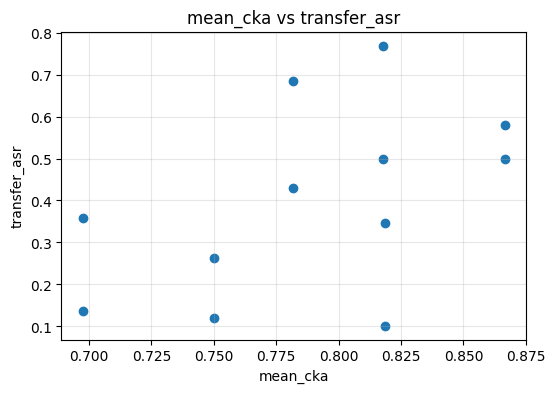

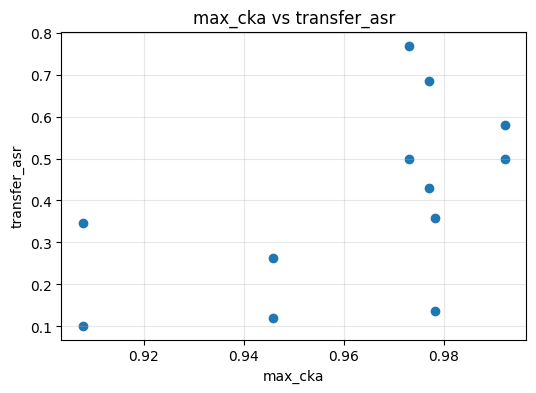

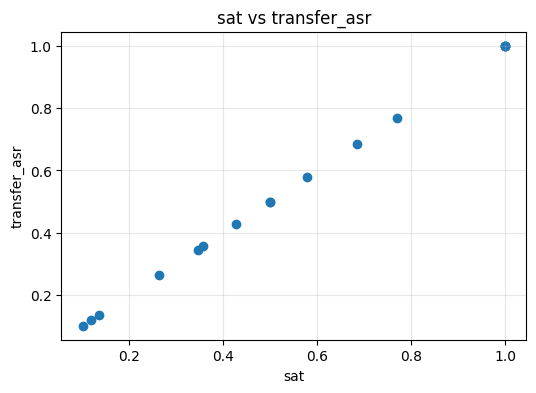

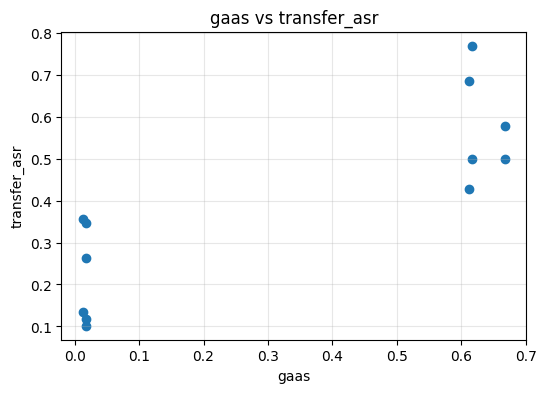

In [13]:
def scatter_metric(df, x, y):
    temp = df[[x, y]].dropna()
    
    if temp.empty:
        print(f"No data for {x} vs {y}")
        return
    
    plt.figure(figsize=(6, 4))
    plt.scatter(temp[x], temp[y])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.grid(True, alpha=0.3)
    plt.show()


if pairwise_df is not None:
    for metric in ["mean_cka", "max_cka", "sat", "gaas"]:
        if metric in pairwise_df.columns and "transfer_asr" in pairwise_df.columns:
            scatter_metric(pairwise_df, metric, "transfer_asr")

Group by training type

In [14]:
if pairwise_df is not None:
    if {"source_training_type", "target_training_type"}.issubset(pairwise_df.columns):
        
        pairwise_df["pair_training_type"] = (
            pairwise_df["source_training_type"].astype(str) +
            " → " +
            pairwise_df["target_training_type"].astype(str)
        )
        
        metric_cols = [
            c for c in ["mean_cka", "max_cka", "sat", "gaas", "transfer_asr"]
            if c in pairwise_df.columns
        ]
        
        training_summary = (
            pairwise_df
            .groupby("pair_training_type")[metric_cols]
            .mean()
            .reset_index()
        )
        
        display(training_summary)
        
        training_output_path = SAVED_DIR / "training_choice_summary.csv"
        training_summary.to_csv(training_output_path, index=False)
        
        print("Saved:", training_output_path)
    
    else:
        print("Missing training type columns.")
        print("Create model_info.csv with: model, architecture, training_type")

,pair_training_type,mean_cka,max_cka,sat,gaas,transfer_asr
0,adversarial_training → adversarial_training,0.866743,0.992234,0.769737,0.668246,0.769737
1,adversarial_training → fast_adversarial_training,0.799767,0.974955,0.726721,0.614413,0.726721
2,adversarial_training → standard,0.784242,0.926834,0.304656,0.018228,0.304656
3,fast_adversarial_training → adversarial_training,0.799767,0.974955,0.464286,0.614413,0.464286
4,fast_adversarial_training → fast_adversarial_t...,NaN,NaN,1.000000,NaN,1.000000
5,fast_adversarial_training → standard,0.697390,0.978288,0.357143,0.012332,0.357143
6,standard → adversarial_training,0.784242,0.926834,0.110169,0.018228,0.110169
7,standard → fast_adversarial_training,0.697390,0.978288,0.135593,0.012332,0.135593
8,standard → standard,NaN,NaN,1.000000,NaN,1.000000


Saved: saved_outputs\training_choice_summary.csv


Training-type plots

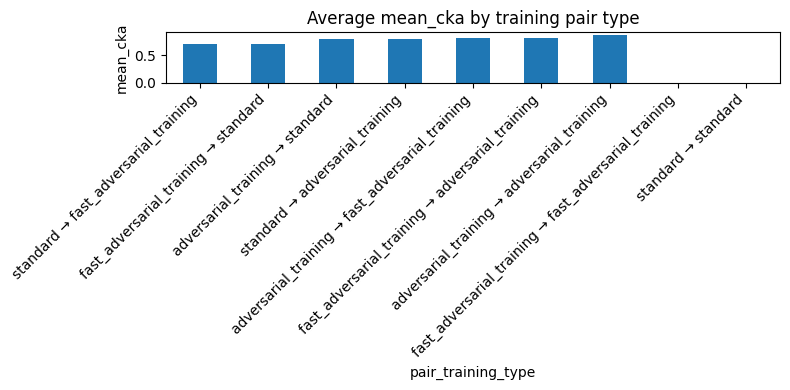

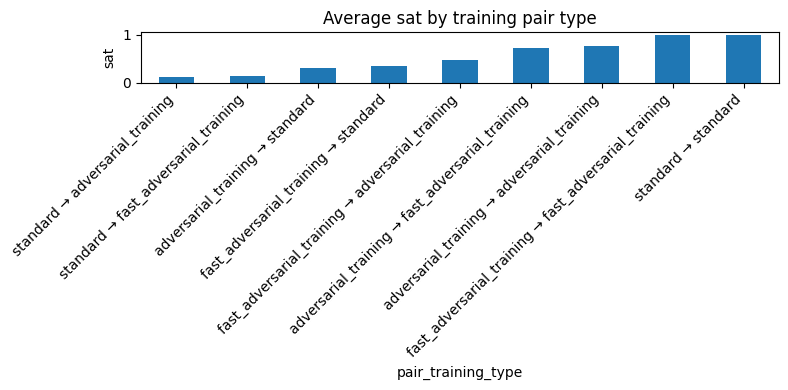

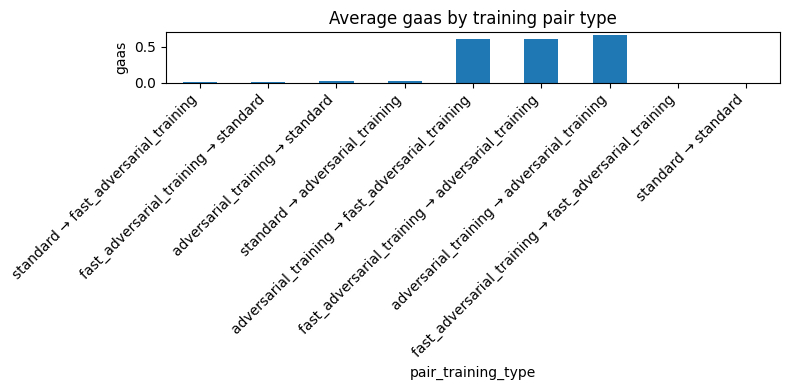

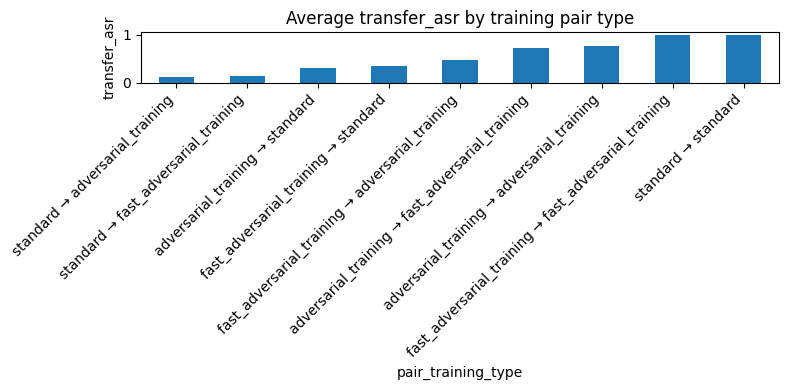

In [15]:
if pairwise_df is not None and "pair_training_type" in pairwise_df.columns:
    
    metric_cols = [
        c for c in ["mean_cka", "sat", "gaas", "transfer_asr"]
        if c in pairwise_df.columns
    ]
    
    for metric in metric_cols:
        plot_df = (
            pairwise_df
            .groupby("pair_training_type")[metric]
            .mean()
            .sort_values()
        )
        
        plt.figure(figsize=(8, 4))
        plot_df.plot(kind="bar")
        plt.ylabel(metric)
        plt.title(f"Average {metric} by training pair type")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

Load transferable example CKA

In [16]:
TRANSFER_EXAMPLE_CKA_PATH = SAVED_DIR / "transferable_example_cka.csv"

example_cka_df = safe_read_csv(
    TRANSFER_EXAMPLE_CKA_PATH,
    "Transferable example CKA"
)

if example_cka_df is not None:
    same_layer_examples = example_cka_df[
        example_cka_df["source_layer"] == example_cka_df["target_layer"]
    ].copy()
    
    example_summary = (
        same_layer_examples
        .groupby(["source_model", "target_model", "source_layer", "transferable"])["cka"]
        .mean()
        .reset_index()
    )
    
    display(example_summary.head())

Loaded Transferable example CKA: (864, 10)


,source_model,target_model,sample_id,source_layer,target_layer,source_layer_name,target_layer_name,cka,transferable,n_samples
0,Standard,Engstrom2019Robustness,-1,1,1,conv1,conv1,0.936069,1,6
1,Standard,Engstrom2019Robustness,-1,1,2,conv1,layer2.0.conv1,0.966831,1,6
2,Standard,Engstrom2019Robustness,-1,1,3,conv1,layer2.3.conv1,0.950659,1,6
3,Standard,Engstrom2019Robustness,-1,1,4,conv1,layer3.2.conv2,0.919965,1,6
4,Standard,Engstrom2019Robustness,-1,1,5,conv1,layer3.5.conv3,0.933734,1,6


,source_model,target_model,source_layer,transferable,cka
0,Engstrom2019Robustness,Rice2020Overfitting,1,0,0.993574
1,Engstrom2019Robustness,Rice2020Overfitting,1,1,0.992736
2,Engstrom2019Robustness,Rice2020Overfitting,2,0,0.986611
3,Engstrom2019Robustness,Rice2020Overfitting,2,1,0.994736
4,Engstrom2019Robustness,Rice2020Overfitting,3,0,0.926375


Plot transferable vs non-transferable divergence

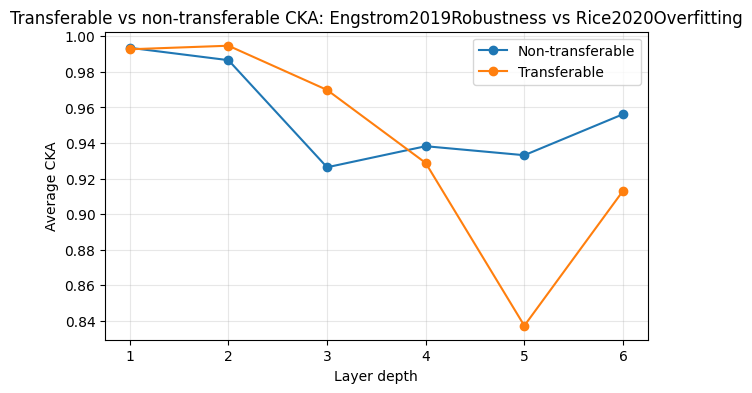

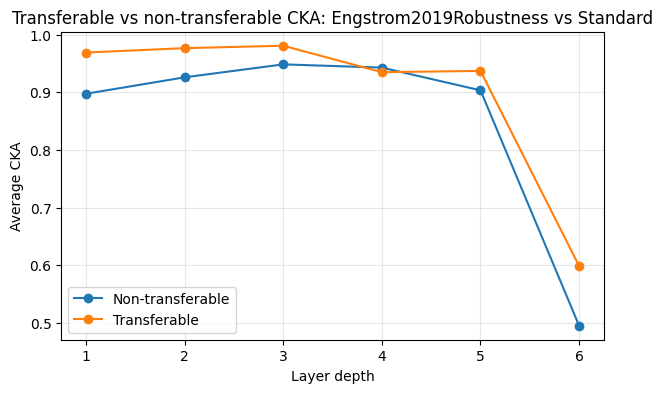

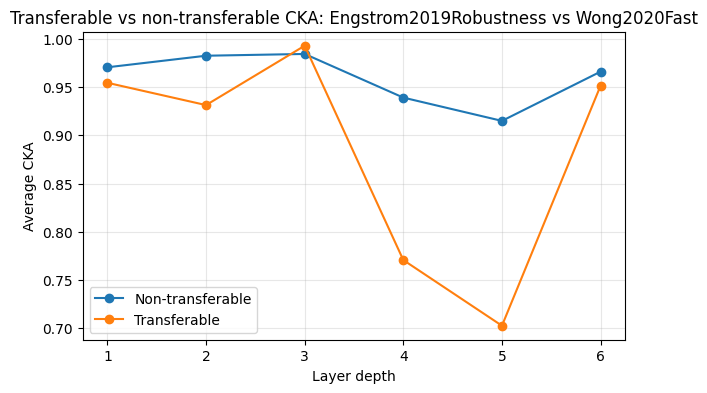

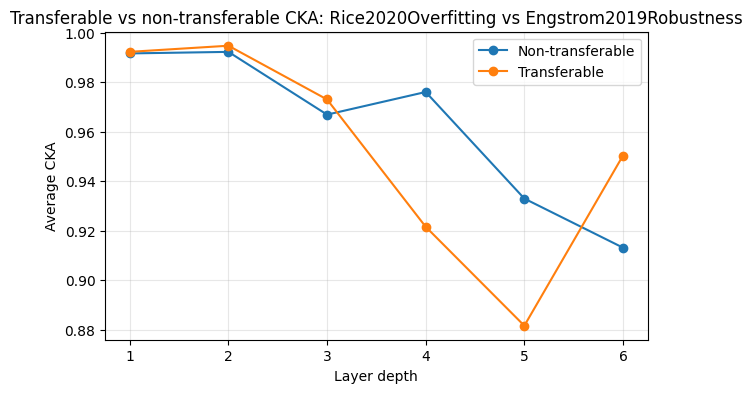

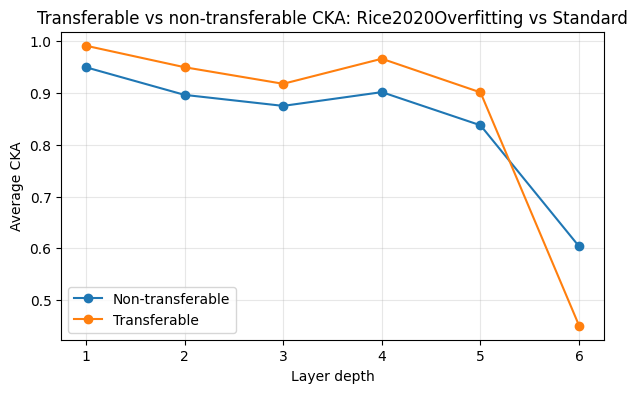

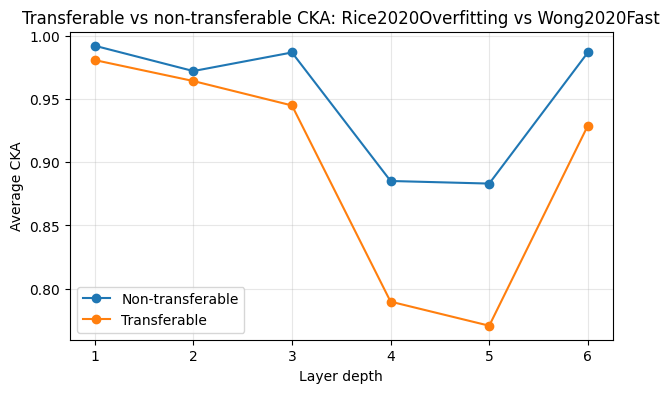

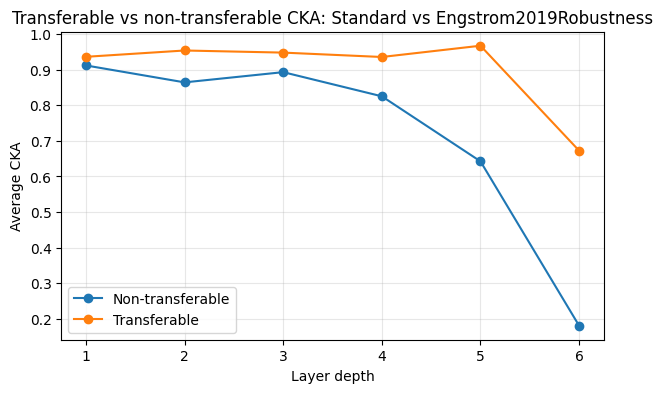

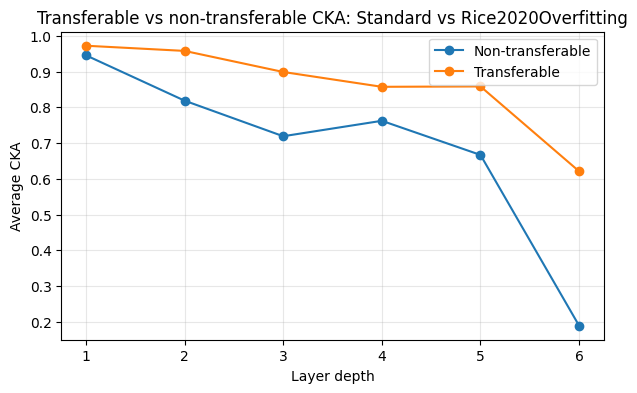

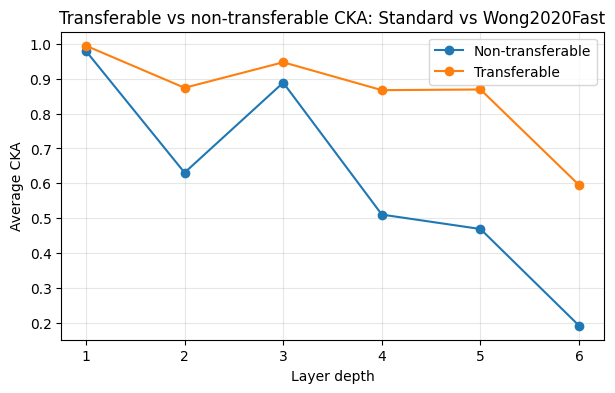

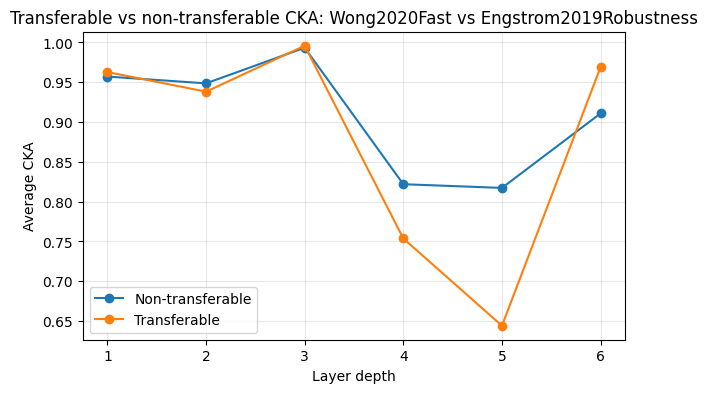

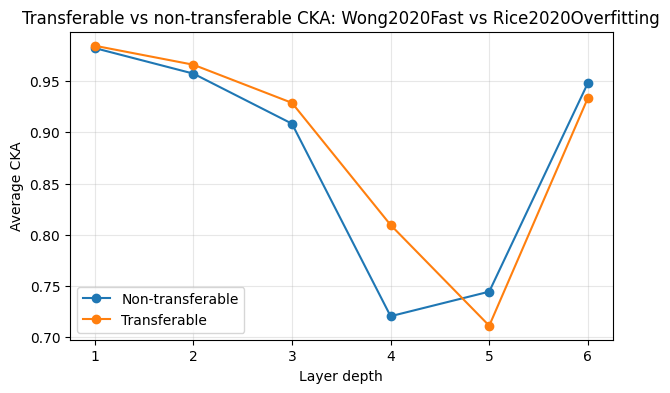

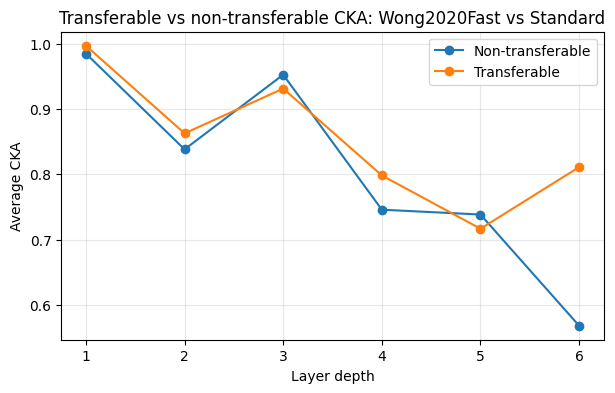

In [17]:
if example_cka_df is not None:
    
    for (src, tgt), group in example_summary.groupby(["source_model", "target_model"]):
        plt.figure(figsize=(7, 4))
        
        for transferable_value, g in group.groupby("transferable"):
            label = "Transferable" if transferable_value == 1 else "Non-transferable"
            g = g.sort_values("source_layer")
            
            plt.plot(
                g["source_layer"],
                g["cka"],
                marker="o",
                label=label
            )
        
        plt.xlabel("Layer depth")
        plt.ylabel("Average CKA")
        plt.title(f"Transferable vs non-transferable CKA: {src} vs {tgt}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

Generate simple written interpretation

In [18]:
def interpret_correlation(corr_df):
    if corr_df is None or corr_df.empty:
        return "Correlation analysis could not be completed because required result files are missing."
    
    lines = []
    
    for _, row in corr_df.iterrows():
        metric = row["x_metric"]
        pearson = row["pearson"]
        spearman = row["spearman"]
        
        if abs(pearson) >= 0.7:
            strength = "strong"
        elif abs(pearson) >= 0.4:
            strength = "moderate"
        elif abs(pearson) >= 0.2:
            strength = "weak"
        else:
            strength = "very weak"
        
        direction = "positive" if pearson > 0 else "negative"
        
        lines.append(
            f"The relationship between {metric} and transfer ASR shows a "
            f"{strength} {direction} correlation "
            f"(Pearson = {pearson:.3f}, Spearman = {spearman:.3f})."
        )
    
    return "\n".join(lines)


if "corr_df" in globals():
    print(interpret_correlation(corr_df))

The relationship between mean_cka and transfer ASR shows a moderate positive correlation (Pearson = 0.488, Spearman = 0.354).
The relationship between max_cka and transfer ASR shows a moderate positive correlation (Pearson = 0.552, Spearman = 0.489).
The relationship between sat and transfer ASR shows a strong positive correlation (Pearson = 1.000, Spearman = 1.000).
The relationship between gaas and transfer ASR shows a strong positive correlation (Pearson = 0.840, Spearman = 0.729).
